In [36]:
# Import necessary libraries
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the dataset
file_path = r'C:\Users\warre\OneDrive\Documents\D604 Task 2\sentiment+labelled+sentences\sentiment labelled sentences\amazon_cells_labelled.txt'
df = pd.read_csv(file_path, names=['review', 'sentiment'], sep='\t')

# Display dataset information
print("Dataset Head:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nChecking for missing values:")
print(df.isnull().sum())

# Check for unusual characters
df['unusual_chars'] = df['review'].apply(lambda x: ''.join([c for c in x if not c.isalnum() and not c.isspace()]))
print("\nUnusual Characters:")
print(df['unusual_chars'].value_counts())

# Define constants for word limit and sequence length
MAX_VOCAB_SIZE = 1880  # Set your vocabulary size limit here
MAX_SEQ_LENGTH = 100    # Set your sequence length limit here

# Statistical justification for maximum sequence length
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
max_seq_length = int(df['review_length'].quantile(0.95))  # 95th percentile
print(f"\nMaximum Sequence Length (95th percentile): {max_seq_length}")

# Ensure sequence length is within the maximum limit
MAX_SEQ_LENGTH = min(max_seq_length, MAX_SEQ_LENGTH)  # Take the smaller of the two
print(f"\nFinal Maximum Sequence Length (after applying limit): {MAX_SEQ_LENGTH}")

# Split dataset into 70% training, 15% validation, and 15% test sets
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = len(df) - train_size - val_size

X_train_d604task2 = df['review'][:train_size].values
y_train_d604task2 = df['sentiment'][:train_size].values

X_val_d604task2 = df['review'][train_size:train_size+val_size].values
y_val_d604task2 = df['sentiment'][train_size:train_size+val_size].values

X_test_d604task2 = df['review'][train_size+val_size:].values
y_test_d604task2 = df['sentiment'][train_size+val_size:].values

# Convert numpy arrays to lists for fitting tokenizer
X_train_d604task2 = X_train_d604task2.tolist()
X_val_d604task2 = X_val_d604task2.tolist()
X_test_d604task2 = X_test_d604task2.tolist()

# Initialize the tokenizer and limit the vocabulary size
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_d604task2 + X_val_d604task2 + X_test_d604task2)

# Now transform texts to sequences, limiting words to the vocabulary size
X_train_d604task2 = tokenizer.texts_to_sequences(X_train_d604task2)
X_val_d604task2 = tokenizer.texts_to_sequences(X_val_d604task2)
X_test_d604task2 = tokenizer.texts_to_sequences(X_test_d604task2)

# Reapply padding, ensuring sequence length is within the limit
X_train_padded = pad_sequences(X_train_d604task2, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_d604task2, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_d604task2, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

# Print shape of the padded sequences to verify
print(f"\nShape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_val_padded: {X_val_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")




Dataset Head:
                                              review  sentiment
0  So there is no way for me to plug it in here i...          0
1                        Good case, Excellent value.          1
2                             Great for the jawbone.          1
3  Tied to charger for conversations lasting more...          0
4                                  The mic is great.          1

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     1000 non-null   object
 1   sentiment  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None

Checking for missing values:
review       0
sentiment    0
dtype: int64

Unusual Characters:
unusual_chars
.           483
,.           91
'.           72
!            34
!.           26
           ... 
',''.         1
(-),','.      1
!!!!!         1
[...]!        1
:-

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re

# Normalize text
df['clean_review'] = df['review'].apply(lambda x: re.sub(r'[^\w\s]', '', x.lower()))

# Tokenize
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_review'])
sequences = tokenizer.texts_to_sequences(df['clean_review'])  # This creates 'sequences'

# Now you can pad
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post')
# Display the first padded sequence for screenshot
print("Sample padded sequence:")
print(padded_sequences[0])



Sample padded sequence:
[ 34 117   6  59 211  12  51   9 154   5  20 331  20   2 540 541   3 237
 186   7 792   0   0]


In [7]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train_d604task2, X_temp_d604task2, y_train_d604task2, y_temp_d604task2 = train_test_split(padded_sequences, df['sentiment'], test_size=0.30, random_state=42)
X_val_d604task2, X_test_d604task2, y_val_d604task2, y_test_d604task2 = train_test_split(X_temp_d604task2, y_temp_d604task2, test_size=0.50, random_state=42)


In [9]:
import numpy as np

# Save prepared padded data with labels
prepared_df = pd.DataFrame(X_train_d604task2)
prepared_df['label'] = np.array(y_train_d604task2)
prepared_df.to_csv('prepared_sentiment_data.csv', index=False)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_seq_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


C:\Users\warre\OneDrive - Western Governors University\tensorflow_env\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train_d604task2, y_train_d604task2, epochs=20, validation_data=(X_val_d604task2, y_val_d604task2), callbacks=[early_stop])


ValueError: Unrecognized data type: x=[[34, 118, 6, 54, 215, 12, 48, 9, 156, 5, 20, 338, 20, 2, 547, 417, 3, 242, 191, 7, 813], [22, 49, 55, 273], [17, 12, 2, 418], [814, 9, 84, 12, 419, 548, 85, 51, 815, 243, 816, 145], [2, 339, 6, 17], [3, 23, 9, 817, 2, 156, 9, 71, 5, 9, 274, 56, 146, 9, 71, 340, 147], [50, 24, 23, 216, 818, 66, 216, 819, 420, 101, 820, 2, 821, 13, 341, 822, 13, 131, 37, 191, 37], [50, 24, 35, 275, 823, 24, 342, 23, 8], [824, 9, 217, 3, 549, 11, 86], [102, 7, 119, 13, 86, 4, 57], [4, 2, 33, 26, 6, 17], [550, 18, 16, 174, 72, 244, 44, 2, 276, 30, 9, 2, 551, 30], [50, 2, 120, 343, 825, 191, 7, 826, 175, 827, 3, 277, 9, 552, 828, 421, 4, 829, 33, 44, 2, 28], [16, 22, 26, 422], [2, 157, 6, 16, 830, 32, 2, 40, 344, 6, 14, 16, 103, 65, 38], [176, 61, 12, 78, 37, 423, 41, 7, 345, 553, 10], [3, 554, 424, 87, 14, 47, 831], [34, 132, 34, 22], [29, 17], [5, 832, 162, 346, 20, 7, 215, 21, 158, 24, 833, 177, 133, 21, 834, 42, 192], [3, 218, 19, 835, 555, 4, 836, 38, 837, 31, 108

Epoch 1/20


C:\Users\warre\OneDrive - Western Governors University\tensorflow_env\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4715 - loss: 0.6951 - val_accuracy: 0.4867 - val_loss: 0.6939
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5552 - loss: 0.6888 - val_accuracy: 0.6200 - val_loss: 0.6871
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6600 - loss: 0.6367 - val_accuracy: 0.7200 - val_loss: 0.5717
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8787 - loss: 0.3132 - val_accuracy: 0.7867 - val_loss: 0.6256
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9577 - loss: 0.1776 - val_accuracy: 0.7867 - val_loss: 0.6108
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9745 - loss: 0.0819 - val_accuracy: 0.7933 - val_loss: 0.8105
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8210 - loss: 0.6342 
Test Loss: 0.6937639713287354
Test Accuracy: 0.8133333325386047


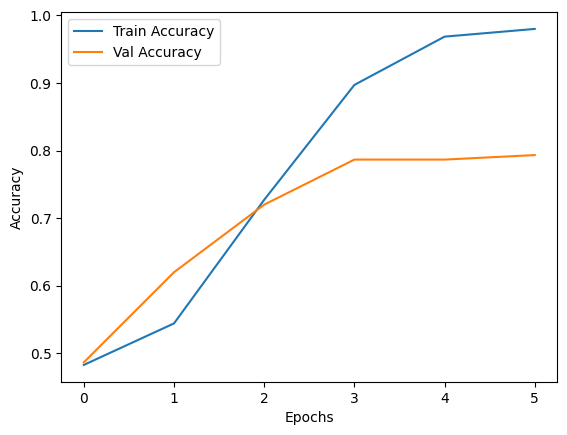

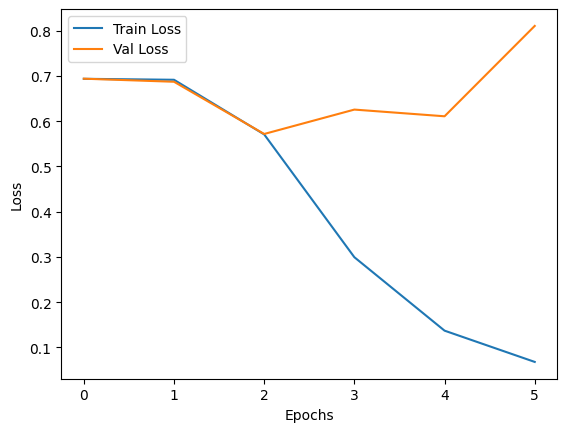

In [38]:
# Build the model
model = Sequential()
model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=100, input_length=MAX_SEQ_LENGTH))  # Input layer with embedding
model.add(LSTM(64))  # LSTM layer
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Initialize early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Train the model
history = model.fit(X_train_padded, y_train_d604task2, epochs=20, validation_data=(X_val_padded, y_val_d604task2), callbacks=[early_stop])

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test_padded, y_test_d604task2)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

# Optional: Plotting the training and validation loss/accuracy
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

